# TOAR-classifier v2: A data-driven classification tool for global air quality stations: Code

In [1]:
# #Install all the required packages for the project by uncommenting this cell (Ctrl+A + ?) and running its
# #Show the current Python executable Jupyter is using
# import sys
# print("Current Python interpreter:", sys.executable)
# print("📦 Installing packages from requirements.txt...")
# !{sys.executable} -m pip install --upgrade pip
# !{sys.executable} -m pip install -r requirements.txt
# print("✅ Installation complete.")

#### ================ Import libraries =======================================

In [32]:
import pandas as pd
import numpy as np
import os
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import *
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score, classification_report
from collections import Counter
from fancyimpute import IterativeImputer
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_style("whitegrid")
font_title = {"family": "serif",
              "color":  "#0b5394", 
              "weight": "bold", 
              "size": 14}
# Graphing…
plt.style.use('fivethirtyeight')
plt.rcParams.update(
    {
     'xtick.labelsize':12,
     'ytick.labelsize':12,
     'axes.labelsize': 12, 
     'legend.fontsize': 12, 
     'axes.titlesize': 12, 
     'axes.titleweight':'bold',
     'axes.titleweight':'bold'
    })

### ===================== Hand-labelled stations for sanity testing ==================

In [33]:
test_coord_urban = ['GB0682A', 'GB1072A', 'GB1095A', 'GB0960A', 'GB1035A', 'DEBE092', 'DEHH026', 'DENW376',  'DEBW118', 'FR04118', 'ES1422A', 'IT1016A', '36-081-0124', '13-121-0001', 
                    '06-037-4002','openaq_225445', 'jp23105510']

test_coord_suburban = ['GB1092A', 'GB0885A', 'FR21031', '06-037-0019', 'jp20421030']

test_coord_rural = ['GB1055R', 'GB0013R', 'GB0006R', 'IE0031R', 'NO0015R', 'FI00363', 'DENI051', 'DENW192', 'DERP015', 'FR23068','FR19020', 'ES1616A', 'IT1942A', 'MT0001R', '37-105-0002',
                     '08-123-0013','06-111-0005', 'openaq_230819', 'openaq_226125', 'jp21601010']

test_coord = {'urban': test_coord_urban, 'suburban': test_coord_suburban, 'rural': test_coord_rural}
categories = ['urban', 'suburban', 'rural']

### ======== Some useful functions for data preparation and preprocessing ==============

In [34]:
def get_station_coord(station_code):
    data_point = requests.get(f'https://toar-data.fz-juelich.de/api/v2/stationmeta/{station_code}').json()
    coord = {}
    coord['lat'] = data_point['coordinates']['lat']
    coord['lon'] = data_point['coordinates']['lng']
    coord['type_of_area'] = data_point['type_of_area']
    coord['alt'] = data_point['coordinates']['alt']
    return coord

def get_test_data_from_station_code(station_codes):
    type_of_area_toar = []
    type_of_area_given = []
    area_code = []
    lat = []
    lon = []
    alt = []
    for area_type, st_code in station_codes.items():
        for code in st_code:
            data_point_coord = get_station_coord(code)
            lat.append(data_point_coord['lat'])
            lon.append(data_point_coord['lon'])
            alt.append(data_point_coord['alt'])
            type_of_area_toar.append(data_point_coord['type_of_area'])
            type_of_area_given.append(area_type)
            area_code.append(code)
    df = pd.DataFrame({'lat':lat, 'lon':lon, 
                       'area_code': area_code,
                       'type_of_area_toar': type_of_area_toar, 
                       'type_of_area_gmap': type_of_area_given})
    df = df[~(df['type_of_area_toar']=='unknown')]
    return df
# #download and save the hand-labelled(label using google map) as csv. 
# test_data = get_test_data_from_station_code(test_coord)
# test_data.to_csv('data/hand_labelled_test_data.csv', index=False)

In [35]:
# This function downloads the dataset from the TAOR-II database. 
# It can be used to refresh the dataset and update the model whenever TAOR-II is updated.
# Note: The dataset has already been downloaded and saved as a CSV file in data folder.
def get_N_first_station_data(data_points=None, N:int=1000, n_sample:int=26): 
    type_of_area = []
    area_code = []
    lat = []
    lon = []
    alt = []
    mean_topography_srtm_alt_90m_year1994 = []
    mean_topography_srtm_alt_1km_year1994 = []
    max_topography_srtm_relative_alt_5km_year1994 = []
    min_topography_srtm_relative_alt_5km_year1994 = []
    stddev_topography_srtm_relative_alt_5km_year1994 =[]
    climatic_zone_year2016 = []
    
    distance_to_major_road_year2020 = []
    mean_stable_nightlights_1km_year2013 = []
    mean_stable_nightlights_5km_year2013 = []
    max_stable_nightlights_25km_year2013 = []
    
    max_stable_nightlights_25km_year1992 = []
    mean_population_density_250m_year2015 = []
    mean_population_density_5km_year2015 = []
    max_population_density_25km_year2015 = []
    mean_population_density_250m_year1990 = []
    mean_population_density_5km_year1990 = []
    max_population_density_25km_year1990 = []
    mean_nox_emissions_10km_year2015 = []
    mean_nox_emissions_10km_year2000 = []
    
    if data_points is None:
        data_points= [requests.get(f'https://toar-data.fz-juelich.de/api/v2/stationmeta/?limit={N}&offset={i*N}').json() for i in range(n_sample)]
        data_points = [datapoint for datapoints_sublist in data_points for datapoint in datapoints_sublist]              
    for data_point in data_points:
        type_of_area.append(data_point['type_of_area'])
        area_code.append(data_point['codes'][0])
        lat.append(data_point['coordinates']['lat'])
        lon.append(data_point['coordinates']['lng'])
        alt.append(data_point['coordinates']['alt'])
        distance_to_major_road_year2020.append(data_point['globalmeta']['distance_to_major_road_year2020'])
        mean_stable_nightlights_1km_year2013.append(data_point['globalmeta']['mean_stable_nightlights_1km_year2013'])
        mean_stable_nightlights_5km_year2013.append(data_point['globalmeta']['mean_stable_nightlights_5km_year2013'])
        max_stable_nightlights_25km_year2013.append(data_point['globalmeta']['max_stable_nightlights_25km_year2013'])
        max_stable_nightlights_25km_year1992.append(data_point['globalmeta']['max_stable_nightlights_25km_year1992'])
        mean_population_density_250m_year2015.append(data_point['globalmeta']['mean_population_density_250m_year2015'])
        mean_population_density_5km_year2015.append(data_point['globalmeta']['mean_population_density_5km_year2015'])
        max_population_density_25km_year2015.append(data_point['globalmeta']['max_population_density_25km_year2015'])
        mean_population_density_250m_year1990.append(data_point['globalmeta']['mean_population_density_250m_year1990'])
        mean_population_density_5km_year1990.append(data_point['globalmeta']['mean_population_density_5km_year1990'])
        max_population_density_25km_year1990.append(data_point['globalmeta']['max_population_density_25km_year1990'])
        mean_nox_emissions_10km_year2015.append(data_point['globalmeta']['mean_nox_emissions_10km_year2015'])
        mean_nox_emissions_10km_year2000.append(data_point['globalmeta']['mean_nox_emissions_10km_year2000'])
        mean_topography_srtm_alt_90m_year1994.append(data_point['globalmeta']['mean_topography_srtm_alt_90m_year1994'])
        mean_topography_srtm_alt_1km_year1994.append(data_point['globalmeta']['mean_topography_srtm_alt_1km_year1994'])
        max_topography_srtm_relative_alt_5km_year1994.append(data_point['globalmeta']['max_topography_srtm_relative_alt_5km_year1994'])
        min_topography_srtm_relative_alt_5km_year1994.append(data_point['globalmeta']['min_topography_srtm_relative_alt_5km_year1994'])
        stddev_topography_srtm_relative_alt_5km_year1994.append(data_point['globalmeta']['stddev_topography_srtm_relative_alt_5km_year1994'])
        climatic_zone_year2016.append(data_point['globalmeta']['climatic_zone_year2016'])
        
    dataset = pd.DataFrame({'lat': lat,
                            'lon': lon,
                            'altitude': alt,
                            'mean_topography_srtm_alt_90m_year1994': mean_topography_srtm_alt_90m_year1994,
                            'mean_topography_srtm_alt_1km_year1994': mean_topography_srtm_alt_1km_year1994,
                            'max_topography_srtm_relative_alt_5km_year1994': max_topography_srtm_relative_alt_5km_year1994,
                            'min_topography_srtm_relative_alt_5km_year1994': min_topography_srtm_relative_alt_5km_year1994,
                            'stddev_topography_srtm_relative_alt_5km_year1994': stddev_topography_srtm_relative_alt_5km_year1994,
                            'climatic_zone_year2016': climatic_zone_year2016,
                            'distance_to_major_road_year2020': distance_to_major_road_year2020,
                            'mean_stable_nightlights_1km_year2013': mean_stable_nightlights_1km_year2013,
                            'mean_stable_nightlights_5km_year2013': mean_stable_nightlights_5km_year2013,
                            'max_stable_nightlights_25km_year2013': max_stable_nightlights_25km_year2013,
                            'max_stable_nightlights_25km_year1992': max_stable_nightlights_25km_year1992,
                            'mean_population_density_250m_year2015': mean_population_density_250m_year2015,
                            'mean_population_density_5km_year2015': mean_population_density_5km_year2015,
                            'max_population_density_25km_year2015': max_population_density_25km_year2015,
                            'mean_population_density_250m_year1990': mean_population_density_250m_year1990,
                            'mean_population_density_5km_year1990': mean_population_density_5km_year1990,
                            'max_population_density_25km_year1990': max_population_density_25km_year1990,
                            'mean_nox_emissions_10km_year2015': mean_nox_emissions_10km_year2015,
                            'mean_nox_emissions_10km_year2000': mean_nox_emissions_10km_year2000,
                            'mean_nox_emissions_10km_year2015': mean_nox_emissions_10km_year2015,
                            'area_code': area_code,
                            'type_of_area': type_of_area
                        })
    return dataset
# # Download the dataset and save as csv file.
#df = get_N_first_station_data()
# df.to_csv('data/stationglobalmetadata.csv', index=False)

In [36]:
#df.to_csv('data/stationglobalmetadatav3.csv', index=False)

In [37]:
def parse_code(series):
    parsed_code = series.str.partition(" ")[0] 
    return pd.to_numeric(parsed_code)

def group_landcover_cat(df):
    landcover = df['dominant_landcover_year2012'].unique()
    dominant_landcover = {}
    for key in landcover:
        dominant_landcover[key] = (key//10)*10
    df['dominant_landcover_year2012'] = df['dominant_landcover_year2012'].replace(dominant_landcover)
    return df

def data_preprocessing(data_frame=None, path_to_data=None, display_duplicate:bool=False, display_inconsistent_example:bool=True):
    """ 
    This function read data as csv file and preprocess it. The prepocessing includes: 
    - replacing -999 and -9999 by NaN (convention for missing values in original dataset)
    - removing rows where all variables are missing (NaN) i.e where all values in 'nan_subset' are missing
    - removing duplicates, remove all duplicate row in the dataset.
    - encoding categorical variables
    """
    if data_frame is not None:
        dataset = data_frame.copy()
    if data_frame is None:
        if path_to_data is not None:
            file_path = os.path.abspath(os.path.join("data", path_to_data))
            dataset = pd.read_csv(file_path)
        else:
            raise NotImplementedError("Unknown dataset")
    if 'lat' in list(dataset.columns) and 'lon' in list(dataset.columns):
        dataset.set_index(['lat', 'lon'], inplace=True)

    dataset.replace(-999.0, np.nan, inplace=True)
    dataset.replace(-9999.0, np.nan, inplace=True)
    dataset.replace(-1.0, np.nan, inplace=True)
    dataset['altitude'].replace(9999.0, np.nan, inplace=True)
    init_shape = dataset.shape
    print("initial data size: ", init_shape)
    dataset['climatic_zone_year2016'] = parse_code(dataset['climatic_zone_year2016'])
    #drop row if all these variables are missing (NaN)
    dataset = dataset[~dataset.index.duplicated(keep='first')]
    
    nan_subset=[
        'mean_topography_srtm_alt_90m_year1994',  
        'mean_topography_srtm_alt_1km_year1994', 
        'max_topography_srtm_relative_alt_5km_year1994',  
        'min_topography_srtm_relative_alt_5km_year1994', 
        'stddev_topography_srtm_relative_alt_5km_year1994', 
        'mean_nox_emissions_10km_year2000',  
        'distance_to_major_road_year2020', 
        'climatic_zone_year2016', 
        'mean_stable_nightlights_1km_year2013'
    ]
    
    if display_inconsistent_example:
        display(dataset[dataset['mean_population_density_5km_year2015']<0])
    dataset.dropna(subset=nan_subset, how='any', inplace=True)  
    dataset = dataset[dataset['mean_nox_emissions_10km_year2000']>=0]
    dataset = dataset[dataset['max_population_density_25km_year2015']>=0]
    dataset = dataset[dataset['mean_population_density_5km_year2015']>=0]
    
    # rows with exactly the same value for variables in 'duplicate'
    duplicate = [
        'altitude', 
        'mean_topography_srtm_alt_90m_year1994', 
        'mean_topography_srtm_alt_1km_year1994',  
        'max_topography_srtm_relative_alt_5km_year1994', 
        'min_topography_srtm_relative_alt_5km_year1994',
        'stddev_topography_srtm_relative_alt_5km_year1994', 
        'climatic_zone_year2016', 
        'distance_to_major_road_year2020', 
        'mean_stable_nightlights_1km_year2013', 
        'mean_stable_nightlights_5km_year2013', 
        'max_stable_nightlights_25km_year2013', 
        'max_stable_nightlights_25km_year1992', 
        'mean_population_density_250m_year2015', 
        'mean_population_density_5km_year2015', 
        'max_population_density_25km_year2015',
        'mean_population_density_250m_year1990', 
        'mean_population_density_5km_year1990', 
        'max_population_density_25km_year1990', 
        'mean_nox_emissions_10km_year2015',
        'mean_nox_emissions_10km_year2000'
    ]
    dataset_duplicate = dataset[dataset.duplicated(keep=False, subset=duplicate)]
    
    if display_duplicate:
        print('Duplicate data points')
        display(dataset_duplicate)
        
    dataset.drop_duplicates(keep=False, subset=duplicate, inplace=True)
    # Fill the missing data
    dataset['altitude'] = dataset['altitude'].fillna(dataset['mean_topography_srtm_alt_90m_year1994'])
    dataset = iterative_imputer(dataset, subset_to_impute=list(dataset.columns)[:-2])
    final_shape = dataset.shape
    print('New shape: ', final_shape)
    print('Total points drop: ', init_shape[0] - final_shape[0])
    eps_nox = sorted(dataset['mean_nox_emissions_10km_year2000'].values)[1]
    eps_nox/=100
    dataset['mean_nox_emissions_10km_year2000'].replace(0.0, eps_nox, inplace=True)
    return dataset

def iterative_imputer(df_, subset_to_impute, estimator=None):
    df=df_.copy()
    df_to_impute = df[subset_to_impute]
    if estimator is None:
        imputer = IterativeImputer()
    elif estimator=='rf':
        imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100))
    elif estimator=='lgbm':
        imputer = IterativeImputer(estimator=LGBMRegressor(verbose=0))
    elif estimator=='cboost':
        imputer = IterativeImputer(CatBoostRegressor(verbose=0))
    else:
        raise NotImplementedError("Unknown estimator")
    df_impute = pd.DataFrame(imputer.fit_transform(df_to_impute), columns=subset_to_impute, index=df.index)
    df[subset_to_impute] = df_impute
    return df

def feature_engineering_selection(data, selected_columns:list=None, scaling:str=None, encode_cat:bool=False, handle_outliers:bool=False, 
                                  columns_maxvalues:dict=None):
    df = data.copy()
    if handle_outliers:
        if columns_maxvalues is None:
            columns_maxvalues = {'altitude':4000, 'mean_nox_emissions_10km_year2015':3.4038e-9, 'distance_to_major_road_year2020': 15000, 
                                 'mean_population_density_5km_year2015': 46000, 'max_topography_srtm_relative_alt_5km_year1994': 2000}
        for col, value in columns_maxvalues.items():
            df[col]  = df[col].where(df[col]<=value, value)
    if selected_columns is None:
        selected_columns = [
            'altitude', 
            'min_topography_srtm_relative_alt_5km_year1994', 
            'mean_topography_srtm_alt_1km_year1994', 
            'distance_to_major_road_year2020', 
            'mean_stable_nightlights_1km_year2013', 
            'mean_stable_nightlights_5km_year2013',
            'max_stable_nightlights_25km_year2013', 
            'mean_population_density_250m_year2015', 
            'mean_population_density_5km_year2015',
            'max_population_density_25km_year2015', 
            'mean_nox_emissions_10km_year2015'
        ]
    df_selected = df[selected_columns]
    if encode_cat:
        if 'climatic_zone_year2016' in list(df_selected.columns):
            df_selected['climatic_zone_year2016'] = df_selected['climatic_zone_year2016'].astype('category')
            df_selected = pd.get_dummies(df_selected, columns=['climatic_zone_year2016'], dtype=float)
        if 'dominant_landcover_year2012' in list(df_selected.columns):
            df_selected['dominant_landcover_year2012'] = df_selected['dominant_landcover_year2012'].astype('category')
            df_selected = pd.get_dummies(df_selected, columns=['dominant_landcover_year2012'], dtype=float)
    if scaling is not None:
        scaling = scaling.lower()
        if scaling=='minmax':
            scaler = MinMaxScaler()
        elif scaling=='standard':
            scaler = StandardScaler()
        elif scaling=='robust':
            scaler = RobustScaler()
        else:
            raise(ValueError('Invalide scaler'))
        numerical_cols = df_selected.select_dtypes(include=['int', 'float']).columns
        df_selected[numerical_cols] = scaler.fit_transform(df_selected[numerical_cols])
    if 'type_of_area' in list(df_selected.columns):
        df_selected = df_selected[[col for col in df_selected.columns if col != 'type_of_area'] + ['type_of_area']]
    return df_selected

In [38]:
def plot_correlation(data, fig_name=' '):
    df = data.select_dtypes(include=['int64', 'float64'])
    corr = df.corr()
    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = True
    fig, ax = plt.subplots(figsize=(22,14))
    ax = sns.heatmap(corr, annot=True, fmt=".3f", annot_kws={'size':9}, mask=mask, center=0, cmap="coolwarm")
    plt.title("Linear correlation heatmap")
    plt.show()
    fig_path = os.path.abspath(os.path.join("figures", fig_name + 'correlation.jpg'))
    plt.savefig(fig_path, dpi=400, bbox_inches='tight')
    return

def boxplot(df):
    import plotly.express as px
    for col in list(df.columns):
        fig = px.box(df, y=col, width=400, height=400)
        fig.show()
    return

def elbow(df, save:bool=False):
    'Determine the number of clusters for kmeans using elbow method'
    cluster_iniertia = []
    for i in range(1, 14):
        kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 500, n_init = 50, random_state = 42)
        kmeans.fit(df)
        cluster_iniertia.append(kmeans.inertia_)
    plt.plot(range(1, 13), cluster_iniertia)
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('cluster_iniertia')
    if save:
        fig_path = os.path.abspath(os.path.join("figures", "elbow_num_clusters.jpg"))
        plt.savefig(fig_path, dpi=400, bbox_inches='tight')
    plt.show()
    return

def cf_matrix(y_true, y_pred, fig_name='_'):
    '''This function will make a pretty plot of an sklearn Confusion Matrix using a Seaborn heatmap visualization'''
    print("Accuracy: {:.2f}%".format(accuracy_score(y_true, y_pred)*100))
    cf_matrix = confusion_matrix(y_true, y_pred)
    class_labels = np.array(['rural', 'suburban', 'urban'])
    fig = plt.figure(figsize=(11, 9))
    sns.set(font_scale=1.4)  # Adjust font scale if necessary
    sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted classes')
    plt.ylabel('True classes')
    plt.title('Confusion Matrix')
    fig_path = os.path.abspath(os.path.join("figures", fig_name + '.jpg'))
    plt.savefig(fig_path, dpi=400, bbox_inches='tight')
    plt.show()
    return 

def to_csv(df, path):
    df = df.reset_index(drop=False)
    df.to_csv(path, index=False)
    return

## Unsupervized approach: Kmeans clustering
**We use only metadata in unservized learning algorithm to find clusters corresponding to different station**

#### Evaluation
**Adjusted Rand Index(ARI)**: Measures the similarity between the true clusters of the samples and the predicted one. It ranges from -1.0 to 1.0
where a score close to 1 indicates strong agreement between the true labels and the clustering algorithm's labels, a score around 0 indicates random labeling, and a negative score indicates disagreement

**Normalized Mutual Information (NMI)**: Measures the mutual information between the true clusters of the samples and the clusters assigned by Kmeans, normalized by the average entropy of the two label sets. It ranges from 0 to 1, where a score close to 1 indicates strong agreement between the true clusters and the Kmeans clusters. A score of 0 indicates no mutual information between the two cluter sets

In [39]:
dataset = data_preprocessing(path_to_data='stationglobalmetadata.csv')
dataset.head(3)

initial data size:  (23969, 22)


,,altitude,mean_topography_srtm_alt_90m_year1994,mean_topography_srtm_alt_1km_year1994,max_topography_srtm_relative_alt_5km_year1994,min_topography_srtm_relative_alt_5km_year1994,stddev_topography_srtm_relative_alt_5km_year1994,climatic_zone_year2016,distance_to_major_road_year2020,mean_stable_nightlights_1km_year2013,mean_stable_nightlights_5km_year2013,...,mean_population_density_250m_year2015,mean_population_density_5km_year2015,max_population_density_25km_year2015,mean_population_density_250m_year1990,mean_population_density_5km_year1990,max_population_density_25km_year1990,mean_nox_emissions_10km_year2015,mean_nox_emissions_10km_year2000,area_code,type_of_area
lat,lon,,,,,,,,,,,,,,,,,,,,,


New shape:  (22378, 22)
Total points drop:  1591


,,altitude,mean_topography_srtm_alt_90m_year1994,mean_topography_srtm_alt_1km_year1994,max_topography_srtm_relative_alt_5km_year1994,min_topography_srtm_relative_alt_5km_year1994,stddev_topography_srtm_relative_alt_5km_year1994,climatic_zone_year2016,distance_to_major_road_year2020,mean_stable_nightlights_1km_year2013,mean_stable_nightlights_5km_year2013,...,mean_population_density_250m_year2015,mean_population_density_5km_year2015,max_population_density_25km_year2015,mean_population_density_250m_year1990,mean_population_density_5km_year1990,max_population_density_25km_year1990,mean_nox_emissions_10km_year2015,mean_nox_emissions_10km_year2000,area_code,type_of_area
lat,lon,,,,,,,,,,,,,,,,,,,,,
-34.3500,18.480,230.0,112.0,84.784127,140.0,-112.0,-68.713116,6.0,24.235018,0.0,0.000000,...,1.339095,0.652963,5356.886333,297.652617,-1.744407,2700.758359,148.964264,101.446434,CPT134S00,rural
46.5475,7.985,3578.0,3466.0,3354.269450,603.0,-2341.0,-2873.715416,7.0,6197.879799,0.0,2.082707,...,0.000000,1.644680,3845.294377,0.000000,1.979643,3047.447108,72.823387,114.493874,CH0001G,unknown
36.2800,100.900,3810.0,3730.0,3697.235165,84.0,-752.0,-3560.781547,8.0,3595.148350,0.0,0.000000,...,0.000000,0.000000,4960.909885,0.000000,0.000000,5311.749164,192.781525,107.847565,WLG,rural


In [40]:
dataset = dataset.sample(frac=1)

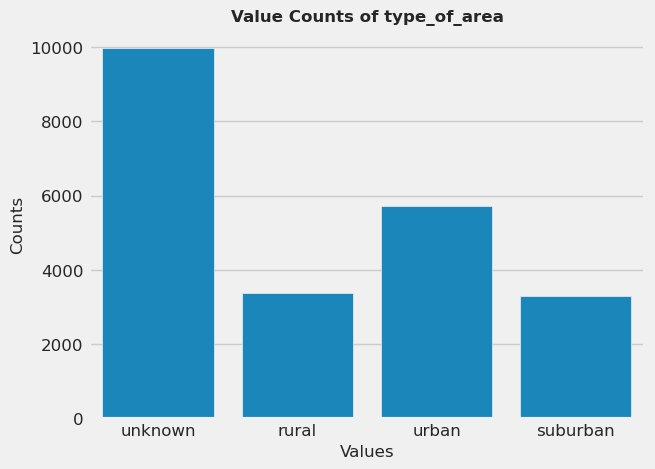

In [41]:
sns.countplot(data=dataset, x='type_of_area')
plt.title('Value Counts of type_of_area')
plt.xlabel('Values')
plt.ylabel('Counts')
fig_path = os.path.abspath(os.path.join("figures", "value_counts_type_of_area.jpg"))
plt.savefig(fig_path, dpi=400, bbox_inches='tight')
plt.show()

### === Functions for training, testing, evaluate clustering algorithm and visualised clusters =====

In [42]:
def train_clustering_model(df, num_clusters:int=3, use_pca:bool=False, model='kmeans'):
    train_model={'pca': None}
    if use_pca:
        pca_ = PCA(n_components=0.95, random_state=42)
        print(f"Original shape: {df.shape}")
        pca = pca_.fit(df)
        df_pca = pca.transform(df)
        print(f"Shape after PCA: {df_pca.shape}")
        df=df_pca
        train_model['pca']=pca
    model=model.lower()
    if model=='kmeans':
        clustering_model= KMeans(n_clusters=num_clusters, n_init=300, random_state=42)
    else:
        raise ValueError('invalid model, Implement another method if needed') # you can implement another method if needed
    clustering_model.fit(df)
    train_model['model']=clustering_model
    return train_model

def cluster_predict(df, train_model):
    kmean=train_model['model']
    pca = train_model['pca']
    if pca is not None:
        df = pca.transform(df)
    y_pred = kmean.predict(df)
    return y_pred

def ari_nmi_clustering(y_pred, y_truth):
    ari = adjusted_mutual_info_score(y_pred, y_truth)
    nmi = normalized_mutual_info_score(y_pred, y_truth)
    return ari, nmi

In [43]:
labelled_data = dataset[~(dataset['type_of_area']=='unknown')]
unlabelled_data = dataset[(dataset['type_of_area']=='unknown')]
df_train, df_test = train_test_split(labelled_data, test_size=0.15, shuffle=False, random_state=42)
df_test_idx = list(df_test.index)
df_train_idx = list(df_train.index)
un_labelled_idx = list(unlabelled_data.index)
print('number of data points: ', dataset.shape)
print("number of known stations: ", labelled_data.shape)
print("number of unknown stations: ", unlabelled_data.shape)
print('test shape: ', df_test.shape)

number of data points:  (22378, 22)
number of known stations:  (12408, 22)
number of unknown stations:  (9970, 22)
test shape:  (1862, 22)


In [44]:
test_data_path = os.path.abspath(os.path.join("data", "hand_labelled_test_data.csv"))
test_data = pd.read_csv(test_data_path)
test_data.set_index(['lat', 'lon'], inplace=True)
test_data = test_data[~(test_data['type_of_area_toar']=='unknown')]
test_indices = list(test_data.index)
test_indices = [idx for idx in test_indices if idx in list(dataset.index)]
test_data = test_data.loc[test_indices]

#### ============ Prepare train and test data and train clustering algorithm ==========

In [45]:
selected_colunms_0 = [
    'altitude', 
    'mean_topography_srtm_alt_90m_year1994', 
    'mean_topography_srtm_alt_1km_year1994', 
    'max_topography_srtm_relative_alt_5km_year1994', 
    'min_topography_srtm_relative_alt_5km_year1994',
    'stddev_topography_srtm_relative_alt_5km_year1994', 
    'climatic_zone_year2016', 
    'distance_to_major_road_year2020', 
    'mean_stable_nightlights_1km_year2013', 
    'mean_stable_nightlights_5km_year2013', 
    'max_stable_nightlights_25km_year2013', 
    'max_stable_nightlights_25km_year1992', 
    'mean_population_density_250m_year2015', 
    'mean_population_density_5km_year2015', 
    'max_population_density_25km_year2015',
    'mean_population_density_250m_year1990', 
    'mean_population_density_5km_year1990', 
    'max_population_density_25km_year1990', 
    'mean_nox_emissions_10km_year2015', 
    'mean_nox_emissions_10km_year2000',
]
dataset_0 = feature_engineering_selection(dataset, selected_columns=selected_colunms_0, scaling='minmax')
df_train_0 = dataset_0[~(dataset_0.index.isin(df_test_idx))]
df_test_0 = dataset_0[(dataset_0.index.isin(df_test_idx))]
test_data_0 = dataset_0.loc[test_indices]
#display(dataset_0.head())
#plot_correlation(df_train_0)

In [46]:
#This cell takes up to ~10 minutes to complete
clustering_model_kmeans = train_clustering_model(df_train_0, model='kmeans', use_pca=False)

#### ===Testing 1: Test K-means clustering on hand-labelled data. Here, we compare the results from the k-means clustering to the manually labeled stations in test_coord (see above). ====

In [23]:
y_pred_0 = cluster_predict(test_data_0, clustering_model_kmeans)
display(y_pred_0)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [25]:
labels_map = {2: 'urban', 0: 'suburban', 1: 'rural'}
labels_map_func = np.vectorize(labels_map.get)

In [26]:
y_pred = labels_map_func(y_pred_0)

In [27]:
y_pred

array(['urban', 'urban', 'urban', 'urban', 'urban', 'urban', 'urban',
       'urban', 'urban', 'urban', 'urban', 'urban', 'urban', 'urban',
       'urban', 'urban', 'suburban', 'suburban', 'rural', 'rural',
       'rural', 'rural', 'rural', 'rural', 'suburban', 'rural', 'rural',
       'rural', 'rural', 'rural', 'rural', 'rural', 'rural'], dtype='<U8')

In [28]:
list(labels_map.values())

['urban', 'suburban', 'rural']

In [29]:
test_data['type_of_area_pred'] = y_pred
accuracy_0 = accuracy_score(test_data['type_of_area_toar'], test_data['type_of_area_pred'])
accuracy_1 = accuracy_score(test_data['type_of_area_gmap'], test_data['type_of_area_pred'])
ari_0, nmi_0 = ari_nmi_clustering(test_data['type_of_area_toar'], test_data['type_of_area_pred'])
ari_1, nmi_1 = ari_nmi_clustering(test_data['type_of_area_gmap'], test_data['type_of_area_pred'])
print("Accuracy w.r.t TOAR labels: {:.2f}%".format(accuracy_0*100))
print("ARI Score w.r.t TOAR labels: {:.2f}".format(ari_0))
print("NMI Score w.r.t TOAR labels: {:.2f}".format(nmi_0))
print()
print("Accuracy w.r.t Google Maps labels: {:.2f}%".format(accuracy_1*100))
print("ARI Score w.r.t Google Maps labels: {:.2f}".format(ari_1))
print("NMI Score w.r.t Google Maps labels: {:.2f}".format(nmi_1))
#test_data['type_of_area_pred'].value_counts()

Accuracy w.r.t TOAR labels: 93.94%
ARI Score w.r.t TOAR labels: 0.77
NMI Score w.r.t TOAR labels: 0.79

Accuracy w.r.t Google Maps labels: 90.91%
ARI Score w.r.t Google Maps labels: 0.71
NMI Score w.r.t Google Maps labels: 0.73


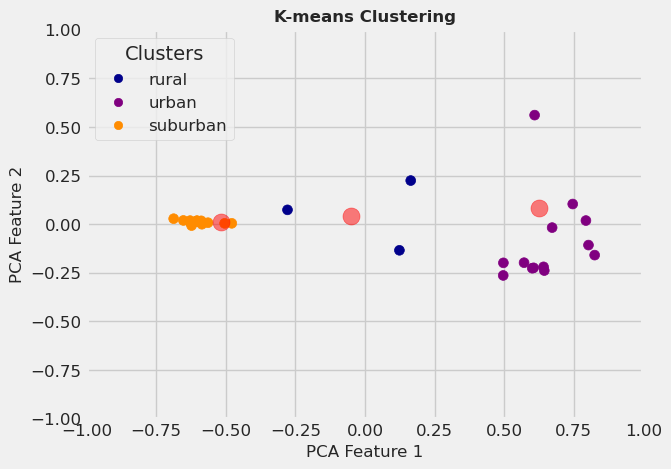

In [30]:
pca = PCA(n_components=2)
test_data_0_pca = pca.fit_transform(test_data_0)
# Plot the clusters
scatter = plt.scatter(test_data_0_pca[:, 0], test_data_0_pca[:, 1], c=y_pred_0, s=50, cmap=ListedColormap(['darkblue', 'purple', 'darkorange'])) # the color order should also be the adjusted base on the above output (y_pred_0) if you get exactly the same plot as in the paper
# Plot centroids
centers = clustering_model_kmeans['model'].cluster_centers_
centers_pca = pca.transform(centers)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=150, alpha=0.5)
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.title('K-means Clustering')
plt.legend(handles=scatter.legend_elements()[0], labels=['rural', 'urban', 'suburban'], loc="best", title="Clusters")
plt.ylim((-1, 1))
plt.xlim((-1, 1))
plt.savefig('figures/kmeans_clusters_0.jpg', dpi=400, pad_inches=0.2, bbox_inches='tight')
plt.show()

#### ======= Test 2: Testing K-mean clustering on 1000 unseen test data =========

Accuracy: 59.08%


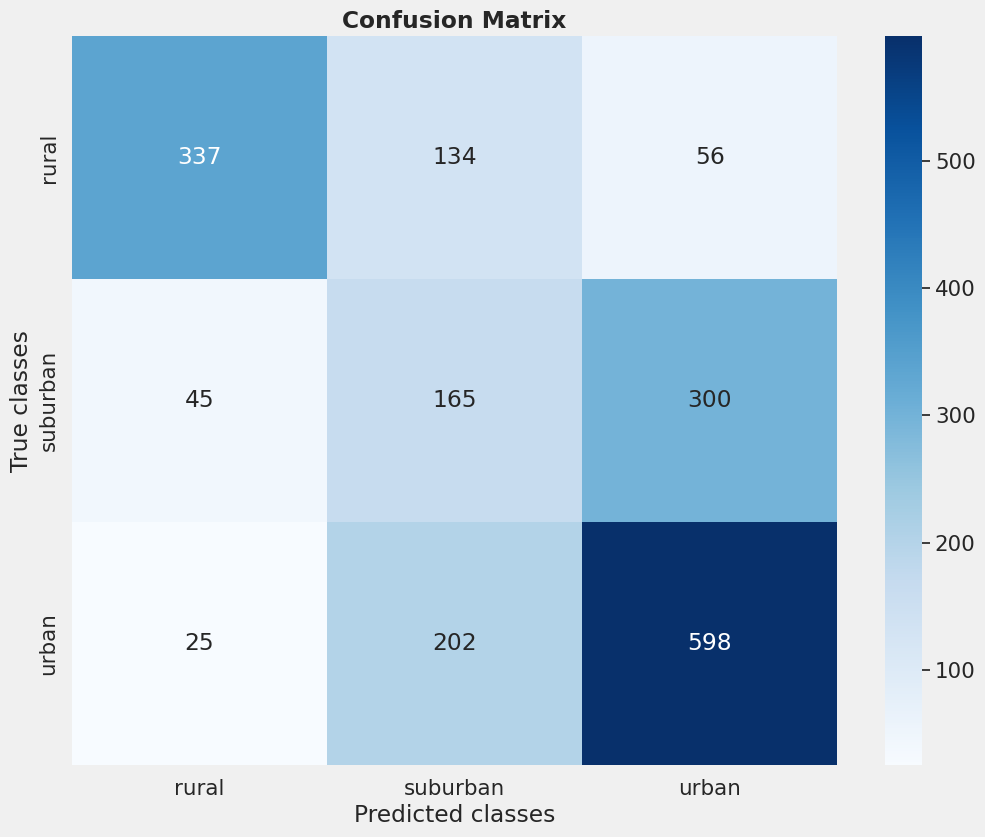

Accuracy: 59.08%
ARI Score : 0.22
NMI Score: 0.22


In [31]:
df_test_result = df_test[['area_code', 'type_of_area']]
y_pred_0 = cluster_predict(df_test_0, clustering_model_kmeans)
df_test_result['type_of_area_pred'] = labels_map_func(y_pred_0)
accuracy_0 = accuracy_score(df_test_result['type_of_area'], df_test_result['type_of_area_pred'])
ari, nmi = ari_nmi_clustering(df_test_result['type_of_area'], df_test_result['type_of_area_pred'])
cf_matrix(df_test_result['type_of_area'], df_test_result['type_of_area_pred'],  fig_name='confision_matrix_kmeans_v2')
print("Accuracy: {:.2f}%".format(accuracy_0*100))
print("ARI Score : {:.2f}".format(ari))
print("NMI Score: {:.2f}".format(nmi))
#display(df_test_result)

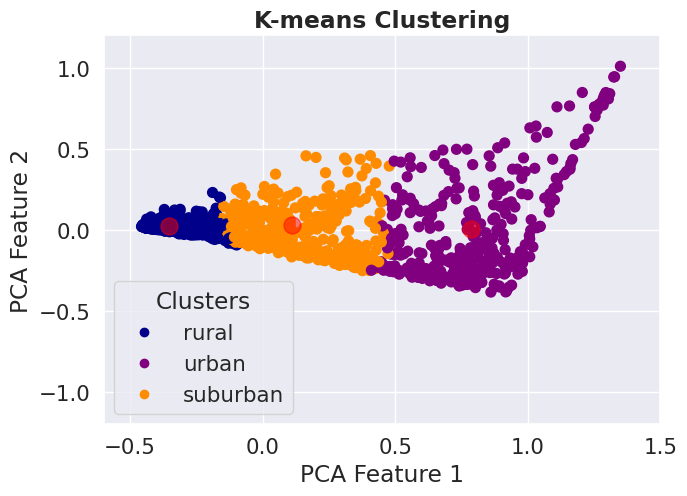

In [202]:
pca = PCA(n_components=2)
df_test_0_pca = pca.fit_transform(df_test_0)
# Plot the clusters
y_pred_0=cluster_predict(df_test_0, clustering_model_kmeans)
scatter = plt.scatter(df_test_0_pca[:, 0], df_test_0_pca[:, 1], c=y_pred_0, s=50, cmap=ListedColormap(['darkblue', 'purple', 'darkorange']))
# Plot centroids
centers = clustering_model_kmeans['model'].cluster_centers_
centers_pca = pca.transform(centers)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=150, alpha=0.5)
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.title('K-means Clustering')
plt.legend(handles=scatter.legend_elements()[0], labels=['rural', 'urban', 'suburban'], loc="best", title="Clusters")
plt.ylim((-1.2, 1.2))
plt.xlim((-.6, 1.5))
plt.savefig('figures/kmeans_clusters_1.jpg', dpi=400, pad_inches=0.2, bbox_inches='tight')
plt.show()

In [23]:
urban_pred = df_test_result[df_test_result['type_of_area']=='urban']
suburban_pred = df_test_result[df_test_result['type_of_area']=='suburban']
rural_pred = df_test_result[df_test_result['type_of_area']=='rural']
print()
print("accuracy for separate test, random forest")
print('accuracy of predicting urban', round(100*accuracy_score(urban_pred['type_of_area'], urban_pred['type_of_area_pred']),2))
print('accuracy of predicting rural', round(100*accuracy_score(rural_pred['type_of_area'], rural_pred['type_of_area_pred']), 2))
print('accuracy of predicting suburan', round(100*accuracy_score(suburban_pred['type_of_area'], suburban_pred['type_of_area_pred']), 2))


accuracy for separate test, random forest
accuracy of predicting urban 69.63
accuracy of predicting rural 24.4
accuracy of predicting suburan 11.11


## Supervised learning approach
Here, we train and evaluate three widely used supervised machine learning models: random forest, CatBoost, and LightGBM, For details, see the paper. 

In [45]:
df_no2 = pd.read_csv('data/no2/p75.csv', comment="#")
df_no2.set_index(['lat', 'lon'], inplace=True)
df_no2 = df_no2.loc[~df_no2.index.duplicated(keep=False)]
df_no2 = df_no2.rename(columns={'value': 'no2'})

df_nox = pd.read_csv('data/nox/p75.csv', comment="#")
df_nox.set_index(['lat', 'lon'], inplace=True)
df_nox = df_nox.loc[~df_nox.index.duplicated(keep=False)]
df_nox = df_nox.rename(columns={'value': 'nox'})
df_nox = df_nox.dropna()

df_pm = pd.read_csv('data/pm2p5/p75.csv', comment="#")
df_pm.set_index(['lat', 'lon'], inplace=True)
df_pm = df_pm.loc[~df_pm.index.duplicated(keep=False)]
df_pm = df_pm.rename(columns={'value': 'pm2p5'})

In [92]:
def predict(clf, X):
    features = get_features_from_clf(clf)
    X_features = X[features]
    y_pred = clf.predict(X_features)
    return y_pred

def predict_proba(clf, X):
    features = get_features_from_clf(clf)
    X_features = X[features]
    y_pred = clf.predict_proba(X_features)
    return y_pred

def voting_clf(clfs:dict, X_test):
    y_pred_voting = []
    y_pred_rf = predict(clfs['rf_clf'], X_test) 
    y_pred_cboost = predict(clfs['cboost'], X_test) 
    y_pred_lgbm = predict(clfs['lgbm'], X_test)
    for pred in zip(y_pred_rf, y_pred_cboost, y_pred_lgbm):
        my_pred = (pred[0], pred[1][0], pred[2])
        counter = Counter(my_pred)
        y_pred_voting.append(counter.most_common(1)[0][0])
    return np.asarray(y_pred_voting, dtype=object)


def threshold_prob_clf(y_proba:np.ndarray):
    y_argmax = np.argmax(y_proba,axis=1)
    y_max = np.max(y_proba,axis=1)
    y_max = y_max >= 0.5
    y_argmax[~y_max] = 1
    classes_ = np.array(['rural', 'suburban', 'urban'], dtype=object)
    y_pred =  classes_[y_argmax]
    return y_pred

def threshold_clf(y_proba:np.ndarray):
    y_pred = []
    for proba in list(y_proba):
        p_max = max(proba)
        if p_max == proba[1]:
            y_pred.append('suburban')
        elif p_max == proba[0] and p_max >= 0.5:
            y_pred.append('rural')
        elif p_max == proba[2] and p_max >= 0.5:
            y_pred.append('urban')
        else:
            y_pred.append('suburban')
    return np.asarray(y_pred, dtype=object)

def prepare_data_for_stat_eval(df_clean, df_spice, know_station_only:bool=False, n_sample:int=1000):
    df = pd.merge(df_clean, df_spice, left_index=True, right_index=True)
    print(df['type_of_area'].value_counts())
    print('total data points: ', df.shape)
    if know_station_only:
        df = df[~((df['type_of_area']=='unknown'))]
        if n_sample is not None:
            n_indiv_sample = int(n_sample/3)
            n_rural = min(len(df[df['type_of_area']=='rural']), n_indiv_sample) 
            n_suburban = min(len(df[df['type_of_area']=='suburban']), n_indiv_sample)       
            n_urban = n_sample - n_rural - n_suburban
            print(n_urban, n_suburban, n_rural)
            df = pd.concat([
                df[df['type_of_area'] == 'urban'].sample(n=n_urban, random_state=42),
                df[df['type_of_area'] == 'suburban'].sample(n=n_suburban, random_state=42),
                df[df['type_of_area'] == 'rural'].sample(n = n_rural, random_state=42)
            ])
    return df

def get_features_from_clf(clf):
    """Extract feature names from a fitted sklearn classifier."""
    if hasattr(clf, 'feature_names_in_'):
        return list(clf.feature_names_in_)
    elif hasattr(clf, 'feature_names_'):
        return list(clf.feature_names_)
    else:
        raise AttributeError(f"Classifier {clf} does not have known feature name attributes.")
 
def stat_evaluation(df_spice, clf, spice:str):
    y_pred = clf.predict(df_spice[get_features_from_clf(clf)])
    df_spice['type_of_area_pred']=y_pred  
    print('accuracy: {:.3f}'.format(accuracy_score(df_spice['type_of_area'].values, df_spice['type_of_area_pred'].values)))
    df_urban = df_spice[df_spice['type_of_area_pred']=='urban']
    df_suburban = df_spice[df_spice['type_of_area_pred']=='suburban']
    df_rural = df_spice[df_spice['type_of_area_pred']=='rural']
    data_clf = [df_urban[spice].values, df_suburban[spice].values, df_rural[spice].values]
    # Creating the box plot
    plt.figure(figsize=(9, 8))
    plt.boxplot(data_clf, patch_artist=True, notch=False, vert=True, showmeans=False, widths=0.15, positions=[0.25, 0.75, 1.25])
    # Adding titles and labels
    plt.title(f'Statistic evaluion {spice}')
    plt.xlabel('Station location')
    plt.ylabel(f'p75 of {spice}')
    plt.xticks([0.25, 0.75, 1.25], ['urban', 'suburban', 'rural'])
    plt.savefig('figures/box_' + spice + '.jpg',  dpi=400, bbox_inches='tight')
    # Display the plot
    plt.show()
    return

def print_prediction_accuracies(df_test_result, model_pred):
    urban_pred = df_test_result[df_test_result['type_of_area']=='urban']
    suburban_pred = df_test_result[df_test_result['type_of_area']=='suburban']
    rural_pred = df_test_result[df_test_result['type_of_area']=='rural']
    for model_name, pred in model_pred.items():
        acc = accuracy_score(df_test_result['type_of_area'].values, df_test_result[pred].values)
        acc_urban = accuracy_score(urban_pred['type_of_area'].values, urban_pred[pred].values)
        acc_suburban = accuracy_score(suburban_pred['type_of_area'].values, suburban_pred[pred].values)
        acc_rural = accuracy_score(rural_pred['type_of_area'].values, rural_pred[pred].values)
        print(f'{model_name}')
        print('global accuracy: ', acc*100)
        print('accuracy for predicting urban: ', round(acc_urban*100, 3))
        print('accuracy for predicting suburban: ', round(acc_suburban*100, 3))
        print('accuracy for predicting rural: ', round(acc_rural*100, 3))
        print()
    return

In [93]:
def train_with_important_feature(clf:dict, X_train, Y_train, X_test=None, Y_test=None, init_num_feature=10):
    # first train
    model = clf['model']
    model_name = clf['model_name']
    model.fit(X_train, Y_train)
    feature_rank = pd.DataFrame({'feature': get_features_from_clf(model), 'importance': model.feature_importances_})
    feature_rank = feature_rank.sort_values('importance', ascending=False)
    features = feature_rank['feature'].to_list()
    num_feature=len(features)
    Y_pred = predict(model, X_test)
    accuracy = accuracy_score(Y_test, Y_pred)
    imp_feature = {'trained_model': model, 'features': features, 'accuracy': accuracy}
    print(accuracy)
    for k in range(num_feature-init_num_feature):
        select_features = features[:init_num_feature+k]
        X_train_selected = X_train[select_features]
        X_test_selected = X_test[select_features]
        model.fit(X_train_selected, Y_train)
        Y_pred = predict(model, X_test_selected)
        acc = accuracy_score(Y_test, Y_pred)
        if acc > imp_feature['accuracy']:
            imp_feature['features']= select_features
            imp_feature['accuracy']=acc
            imp_feature['model'] = model
    print(imp_feature['accuracy'])
    return imp_feature

def plot_feature_importance(trained_clf, model_name:str=None, save_plot:bool=False):
    feature_rank = pd.DataFrame({'features': get_features_from_clf(trained_clf), 'importance': trained_clf.feature_importances_})
    feature_rank = feature_rank.sort_values('importance', ascending=False)
    plt.figure(figsize=(6, 8))
    sns.barplot(y='features', x='importance', data=feature_rank)
    plt.title(f"feature importance for {model_name}", size=10)
    if save_plot:
        plt.savefig(f"figures/features_importances_{model_name}.jpg", dpi=400, bbox_inches='tight')
    plt.show()

#### ====================== Prepare data ==================================

In [94]:
dataset = data_preprocessing(data_frame=df)
dataset_origin = dataset.copy()
data = dataset_origin.sample(frac=1)

initial data size:  (24348, 22)
New shape:  (23517, 22)
Total points drop:  831


In [95]:
labelled_data = data[~(data['type_of_area']=='unknown')]
unlabelled_data = data[(data['type_of_area']=='unknown')]
y = labelled_data['type_of_area']
print('number of data points: ', data.shape)
print("number of known stations: ", labelled_data.shape)
print('number of unlabelled stations: ', unlabelled_data.shape)
df_train, df_test = train_test_split(labelled_data, test_size=0.15, stratify=y, random_state=42)
print('training shape: ', df_train.shape)
print('test shape: ', df_test.shape)
df_test_idx = list(df_test.index)
df_train_idx = list(df_train.index)
labelled_idx = list(labelled_data.index)
unlabelled_idx = list(unlabelled_data.index)

number of data points:  (23517, 22)
number of known stations:  (12894, 22)
number of unlabelled stations:  (10623, 22)
training shape:  (10959, 22)
test shape:  (1935, 22)


In [96]:
test_data = pd.read_csv('data/hand_labelled_test_data.csv')
test_data.set_index(['lat', 'lon'], inplace=True)
test_indices = list(test_data.index)
test_indices = [idx for idx in test_indices if idx in list(labelled_data.index)]
test_data = test_data.loc[test_indices]

In [97]:
selected_colunms_0 = [
    'area_code',
    'altitude',
    'mean_topography_srtm_alt_90m_year1994', 
    'mean_topography_srtm_alt_1km_year1994', 
    'max_topography_srtm_relative_alt_5km_year1994', 
    'min_topography_srtm_relative_alt_5km_year1994',
    'stddev_topography_srtm_relative_alt_5km_year1994', 
    'distance_to_major_road_year2020', 
    'climatic_zone_year2016', 
    'mean_stable_nightlights_5km_year2013',
    'max_stable_nightlights_25km_year1992', 
    'mean_population_density_250m_year2015', 
    'mean_population_density_5km_year2015', 
    'max_population_density_25km_year2015', 
    'mean_population_density_250m_year1990', 
    'mean_population_density_5km_year1990', 
    'max_population_density_25km_year1990', 
    'mean_nox_emissions_10km_year2015', 
    'mean_nox_emissions_10km_year2000', 
    'type_of_area'
]
dataset_0 = feature_engineering_selection(data, selected_columns=selected_colunms_0, scaling='robust', encode_cat=False)
#plot_correlation(dataset_0[list(dataset_0.columns)[:-1]])
df_train_0 = dataset_0.loc[df_train_idx]
df_test_0 = dataset_0.loc[df_test_idx]
print('training shape: ', df_train_0.shape[0])
print('unkwon station: ', len(unlabelled_idx))
print('test shape: ', df_test_0.shape[0])
df_unlabelled_0 = dataset_0.loc[unlabelled_idx]
test_data_0 = dataset_0.loc[test_indices]
#display(df_train_0.head(2))
X_train_0 = df_train_0.drop(columns=['area_code', 'type_of_area'])
Y_train_0 = df_train_0[['type_of_area']]
X_test_0 = df_test_0.drop(columns=['area_code', 'type_of_area'])
Y_test_0 = df_test_0[['type_of_area']]

training shape:  10959
unkwon station:  10623
test shape:  1935


In [147]:
cl_weights = {'urban': 0.275, 'suburban':0.45, 'rural':0.275}
rf_clf = RandomForestClassifier(n_estimators=500, criterion = 'entropy', random_state = 42, class_weight='balanced')

cboost_clf = CatBoostClassifier(n_estimators=500, learning_rate= 0.04, depth= 9, l2_leaf_reg= 6, random_strength= 3.45, min_data_in_leaf= 50, bootstrap_type = 'MVS', verbose=False)

lgbm_clf =  LGBMClassifier(n_estimators=500, is_unbalance=True, verbose=0)

#### ===================== Train machine learning (ML) models =======================

In [148]:
# This cell takes up to ~1minutes to complete
rf_clf.fit(X_train_0, Y_train_0)
cboost_clf.fit(X_train_0, Y_train_0)
lgbm_clf.fit(X_train_0, Y_train_0)

LGBMClassifier(is_unbalance=True, n_estimators=500, verbose=0)

In [ ]:
# #Uncomment this cell if you want to train models with important features, this can take up to 20 minutes
# print('training lgbm')
# selected_feature_lgbm = train_with_important_feature({'model_name': 'lgbm', 'model': lgbm_clf}, X_train_0, Y_train_0, X_test_0, Y_test_0, init_num_feature=15)
# print('training rf')
# selected_feature_rf = train_with_important_feature({'model_name': 'rf', 'model': rf_clf}, X_train_0, Y_train_0, X_test_0, Y_test_0, init_num_feature=15)
# print('training cboost')
# selected_feature_cboost = train_with_important_feature({'model_name': 'cboost', 'model': cboost_clf}, X_train_0, Y_train_0, X_test_0, Y_test_0, init_num_feature=15)

training lgbm
0.768
0.77
training rf
0.753
0.762
training cboost
0.752
0.757


In [154]:
y_pred_prob_rf=predict_proba(rf_clf, test_data_0)
y_pred_prob_cboost=predict_proba(cboost_clf, test_data_0)
y_pred_prob_lgbm=predict_proba(lgbm_clf, test_data_0) 
y_pred_prob_voting = (y_pred_prob_rf + y_pred_prob_cboost + y_pred_prob_lgbm)/3
rf_clf.classes_

array(['rural', 'suburban', 'urban'], dtype=object)

In [155]:
test_data['type_of_area_pred_rf'] =  predict(rf_clf, test_data_0)
test_data['type_of_area_pred_thr_voting'] = threshold_clf(y_pred_prob_voting)
test_data['type_of_area_voting'] = test_data[['type_of_area_gmap', 'type_of_area_pred_rf', 'type_of_area_pred_thr_voting']].apply(lambda row: Counter(row).most_common(1)[0][0], axis=1)
Acc_0 = accuracy_score(test_data['type_of_area_toar'].values, test_data['type_of_area_pred_rf'].values)
Acc_1 = accuracy_score(test_data['type_of_area_gmap'].values, test_data['type_of_area_pred_rf'].values)
Acc_2 = accuracy_score(test_data['type_of_area_toar'].values, test_data['type_of_area_pred_thr_voting'].values)
Acc_3 = accuracy_score(test_data['type_of_area_gmap'].values, test_data['type_of_area_pred_thr_voting'].values)

print("Accuracy of random forest w.r.t TOAR labels : {:.2f}%".format(Acc_0*100))
print("Accuracy of random forest w.r.t Google Maps labels: {:.2f}%".format(Acc_1*100))
print()
print("Accuracy of voting w.r.t TOAR labels: {:.2f}%".format(Acc_2*100))
print("Accuracy of voting w.r.t Google Maps labels: {:.2f}%".format(Acc_3*100))

Accuracy of random forest w.r.t TOAR labels : 100.00%
Accuracy of random forest w.r.t Google Maps labels: 86.67%

Accuracy of voting w.r.t TOAR labels: 100.00%
Accuracy of voting w.r.t Google Maps labels: 86.67%


In [156]:
y_pred_prob_rf=predict_proba(rf_clf, X_test_0)
y_pred_prob_cboost=predict_proba(cboost_clf, X_test_0)
y_pred_prob_lgbm=predict_proba(lgbm_clf, X_test_0)
y_pred_prob_voting = (y_pred_prob_rf + y_pred_prob_cboost + y_pred_prob_lgbm)/3

In [157]:
y_pred_0_rf = predict(rf_clf, X_test_0)
y_pred_0_cboost = predict(cboost_clf, X_test_0)
y_pred_0_lgbm = predict(lgbm_clf, X_test_0)
df_test_result = df_test[['area_code', 'type_of_area']]
df_test_result['type_of_area_pred_rf'] = y_pred_0_rf
df_test_result['type_of_area_pred_cboost'] = y_pred_0_cboost.reshape(len(y_pred_0_rf), )
df_test_result['type_of_area_pred_lgbm'] = y_pred_0_lgbm
df_test_result['type_of_area_pred_voting'] = df_test_result[['type_of_area_pred_rf', 'type_of_area_pred_cboost', 'type_of_area_pred_lgbm']].apply(lambda row: Counter(row).most_common(1)[0][0], axis=1)

In [158]:
#Results before threshold adjustment
model_pred = {'Random Forest':'type_of_area_pred_rf', 'Lgbm': 'type_of_area_pred_lgbm', 'CatBoost': 'type_of_area_pred_cboost',  'Voting': 'type_of_area_pred_voting'}
print_prediction_accuracies(df_test_result, model_pred)

Random Forest
global accuracy:  74.83204134366926
accuracy for predicting urban:  84.912
accuracy for predicting suburban:  48.633
accuracy for predicting rural:  83.107

Lgbm
global accuracy:  75.65891472868216
accuracy for predicting urban:  83.04
accuracy for predicting suburban:  55.469
accuracy for predicting rural:  82.718

CatBoost
global accuracy:  75.03875968992249
accuracy for predicting urban:  83.811
accuracy for predicting suburban:  51.953
accuracy for predicting rural:  82.524

Voting
global accuracy:  75.03875968992249
accuracy for predicting urban:  84.141
accuracy for predicting suburban:  50.781
accuracy for predicting rural:  83.107



In [159]:
# Applying threshold adjustment
y_pred_0_rf = threshold_clf(predict_proba(rf_clf, X_test_0)) 
y_pred_0_cboost = threshold_clf(predict_proba(cboost_clf, X_test_0)) 
y_pred_0_lgbm = threshold_clf(predict_proba(lgbm_clf, X_test_0))
df_test_result = df_test[['area_code', 'type_of_area']]
df_test_result['type_of_area_pred_rf'] = y_pred_0_rf
df_test_result['type_of_area_pred_cboost'] = y_pred_0_cboost.reshape(len(y_pred_0_rf), )
df_test_result['type_of_area_pred_lgbm'] = y_pred_0_lgbm
df_test_result['type_of_area_pred_voting'] = threshold_clf(y_pred_prob_voting)

In [146]:
#Results after threshold adjustment
model_pred = {'Random Forest':'type_of_area_pred_rf', 'Lgbm': 'type_of_area_pred_lgbm', 'CatBoost': 'type_of_area_pred_cboost',  'Voting': 'type_of_area_pred_voting'}
print_prediction_accuracies(df_test_result, model_pred)

Random Forest
global accuracy:  74.36692506459949
accuracy for predicting urban:  82.159
accuracy for predicting suburban:  54.688
accuracy for predicting rural:  80.194

Lgbm
global accuracy:  74.26356589147287
accuracy for predicting urban:  81.167
accuracy for predicting suburban:  57.031
accuracy for predicting rural:  79.223

CatBoost
global accuracy:  72.24806201550388
accuracy for predicting urban:  80.286
accuracy for predicting suburban:  53.906
accuracy for predicting rural:  76.311

Voting
global accuracy:  74.67700258397933
accuracy for predicting urban:  82.599
accuracy for predicting suburban:  57.031
accuracy for predicting rural:  78.252



Accuracy: 75.60%


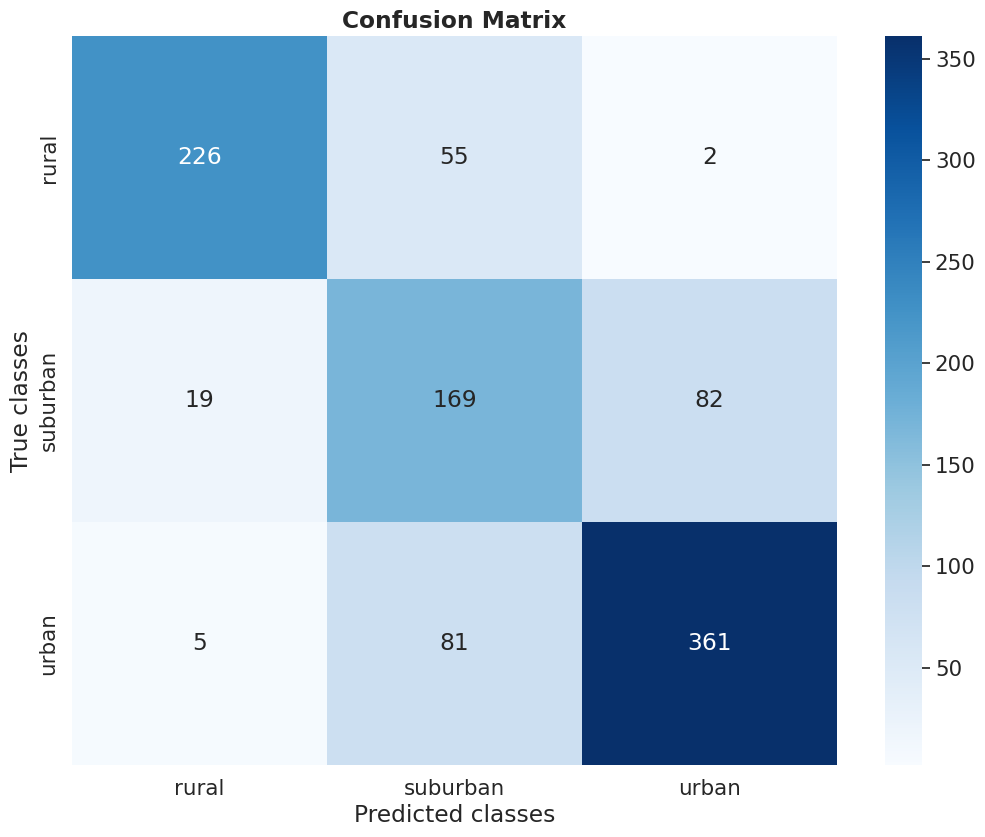

type_of_area
urban       447
rural       283
suburban    270
Name: count, dtype: int64

In [119]:
cf_matrix(
    df_test_result['type_of_area'].values,
    df_test_result['type_of_area_pred_rf'].values,
    fig_name='confusion_matrix_rf')
df_test_result['type_of_area'].value_counts()

Accuracy: 75.10%


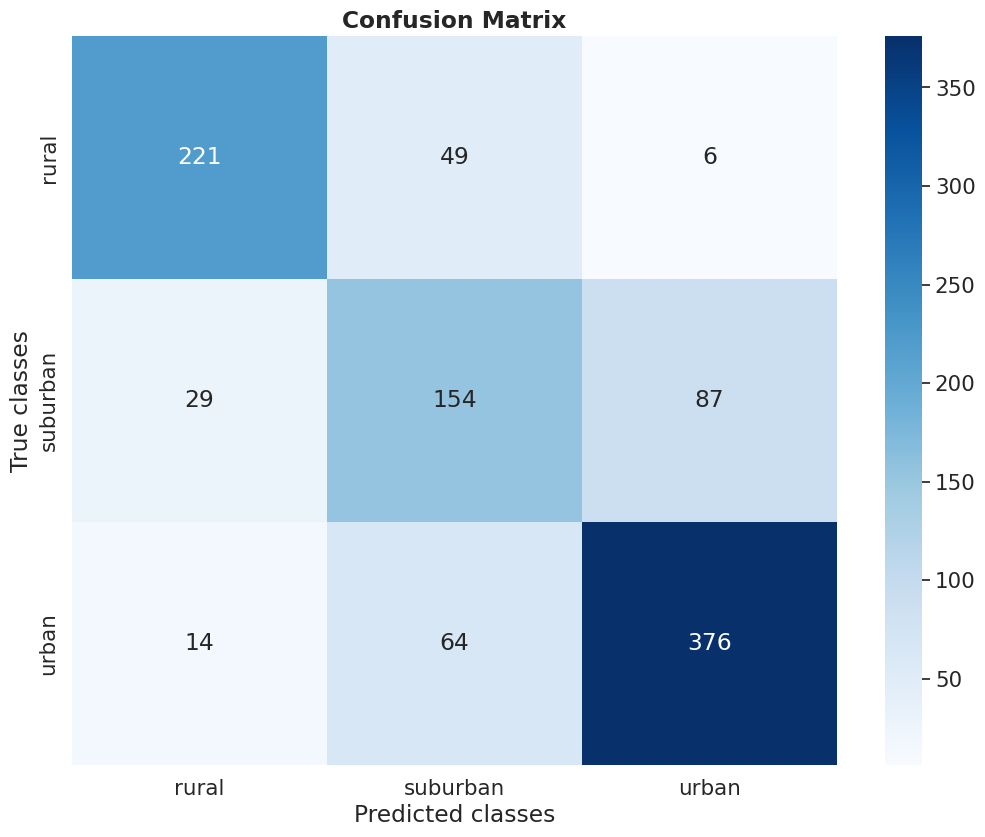

type_of_area
urban       454
rural       276
suburban    270
Name: count, dtype: int64

In [41]:
cf_matrix(
    df_test_result['type_of_area'].values,
    df_test_result['type_of_area_pred_voting'].values,
    fig_name='confusion_matrix_voting')
df_test_result['type_of_area'].value_counts()

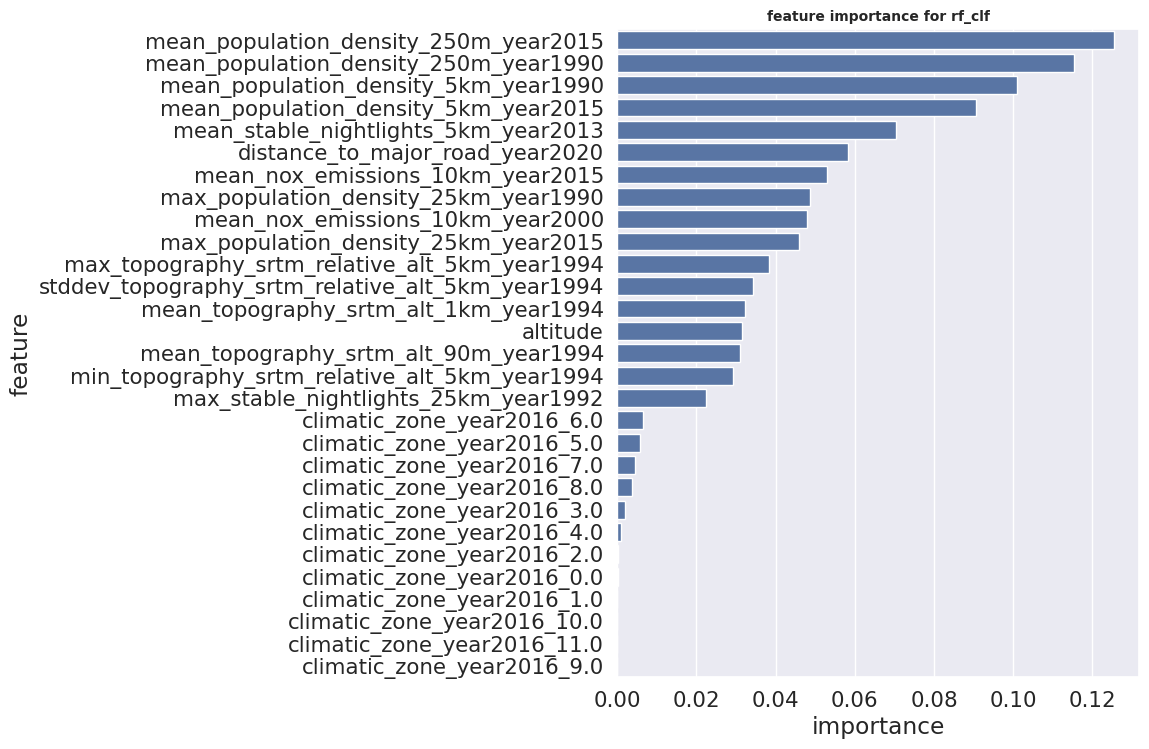

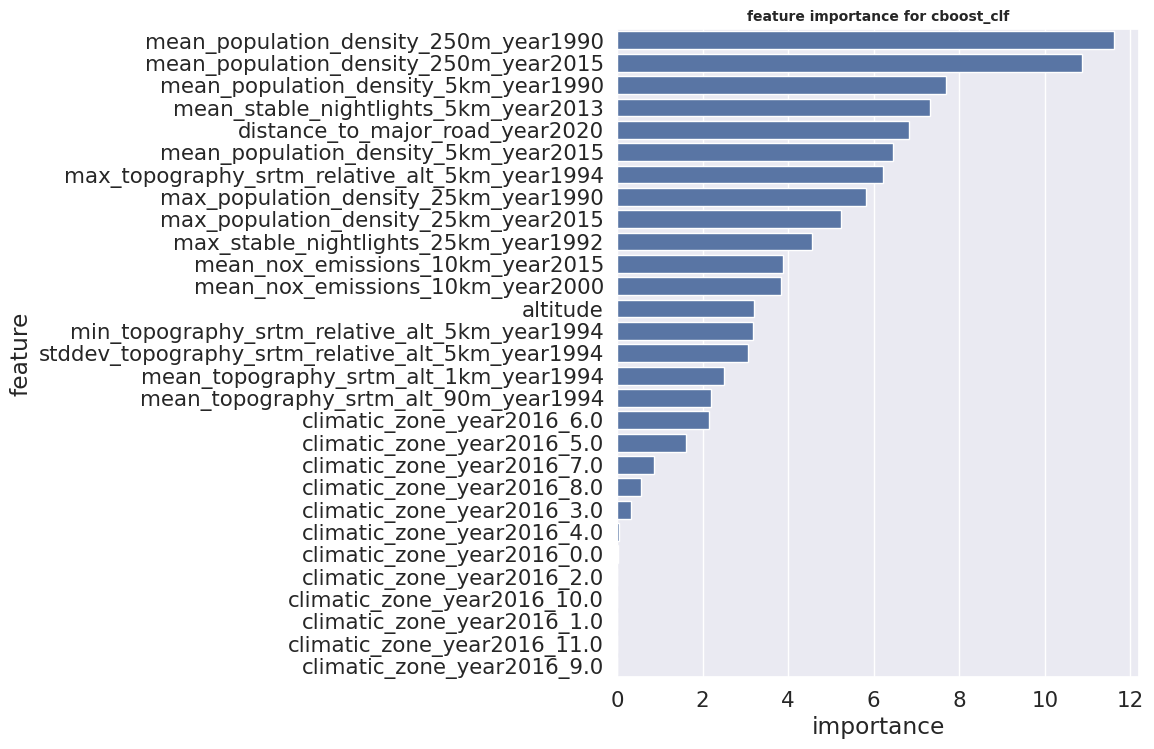

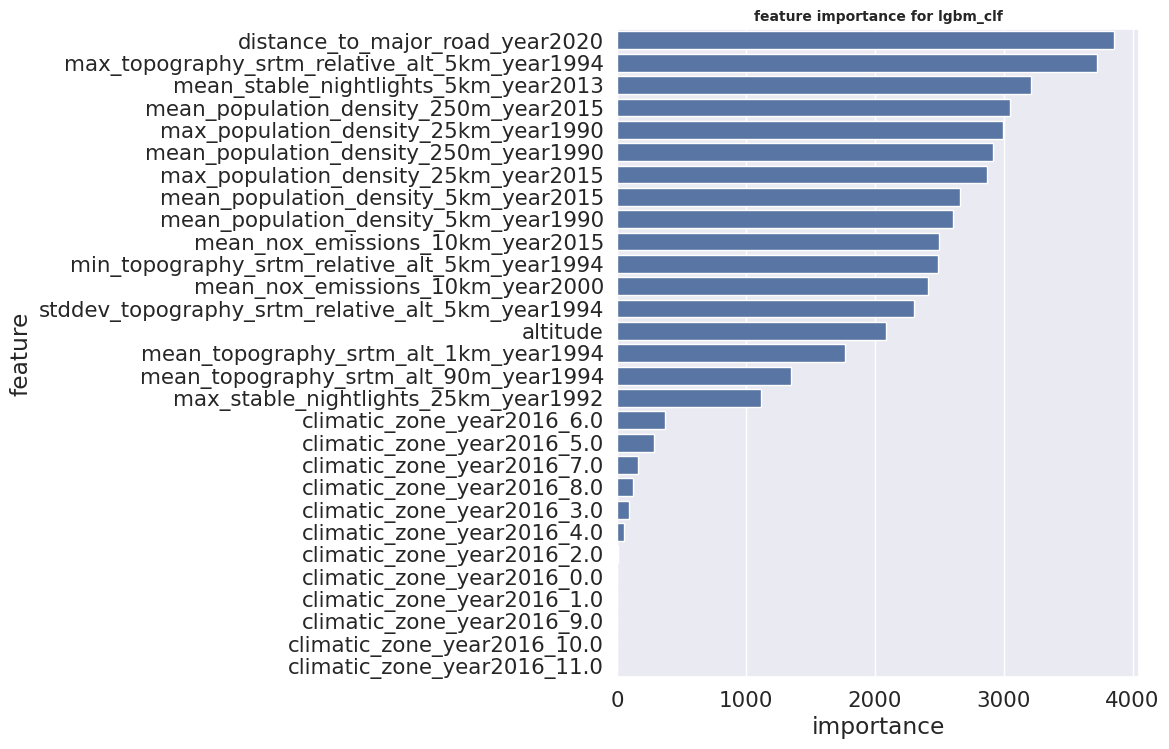

In [146]:
plot_feature_importance(rf_clf, 'rf_clf', save_plot=True)
plot_feature_importance(cboost_clf, 'cboost_clf', save_plot=True)
plot_feature_importance(lgbm_clf, 'lgbm_clf', save_plot=True)

#### ========================= Statistics evaluation =========================

type_of_area
urban       783
suburban    380
rural       309
unknown     207
Name: count, dtype: int64
total data points:  (1679, 33)
358 333 309
accuracy: 0.981


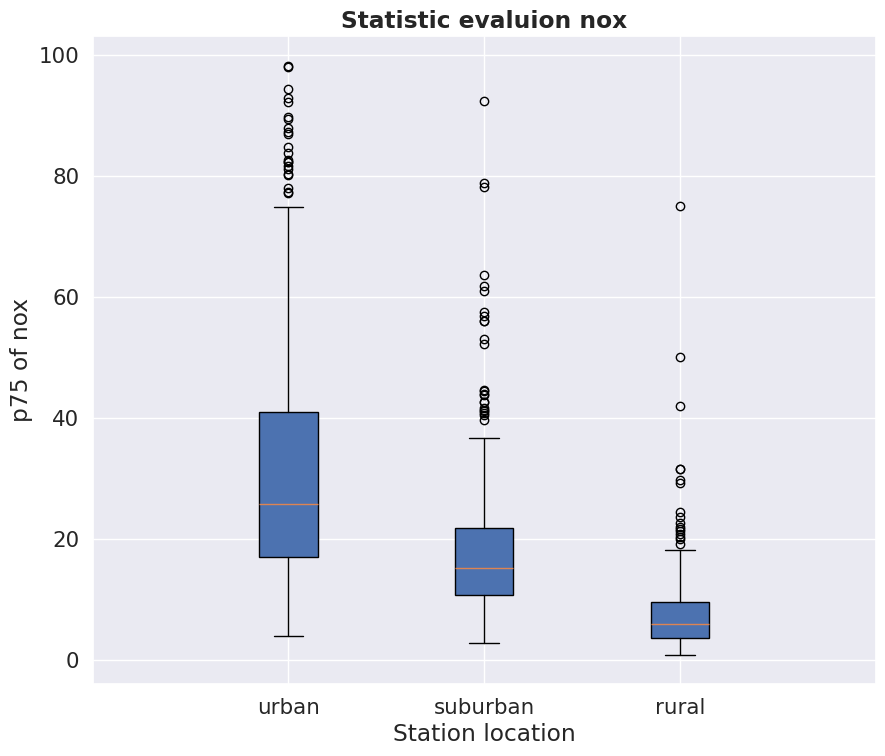

In [150]:
df_test_nox = prepare_data_for_stat_eval(dataset_0, df_nox, know_station_only=True)
stat_evaluation(df_test_nox[df_test_nox['nox']<=100], rf_clf, 'nox')

type_of_area
urban       863
unknown     375
suburban    312
rural       244
Name: count, dtype: int64
total data points:  (1794, 33)
444 312 244
accuracy: 0.973


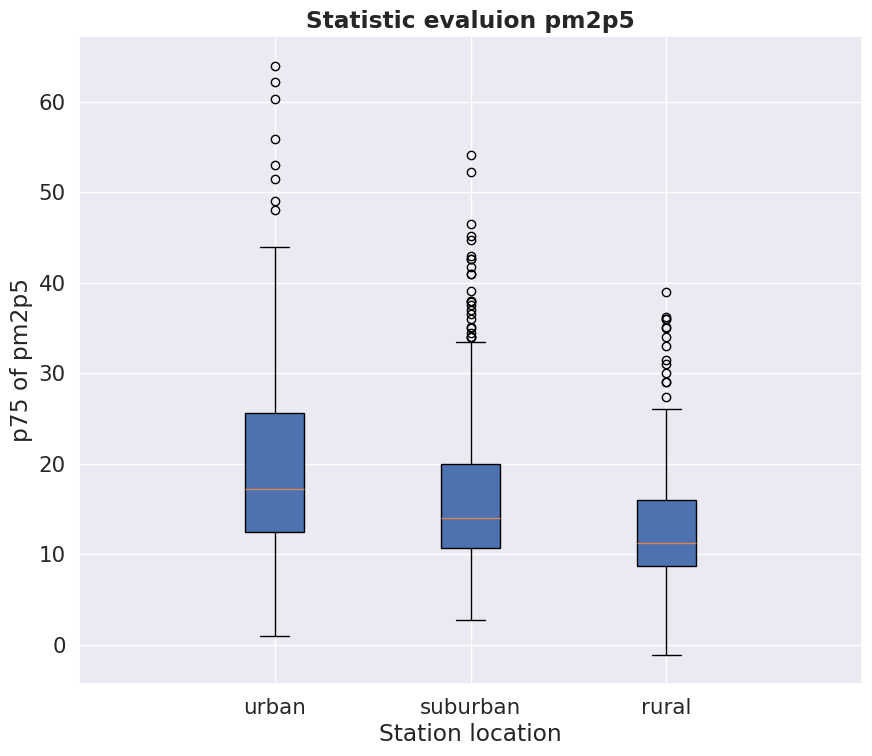

In [151]:
df_test_pm = prepare_data_for_stat_eval(dataset_0, df_pm, know_station_only=True)
stat_evaluation(df_test_pm[df_test_pm['pm2p5']<=70], rf_clf, 'pm2p5')

### ====================== Predict unknown stations =========================

In [54]:
df_unlabelled_idxcode = dataset.loc[unlabelled_idx]
Y_unlabelled_pred_rf = predict(rf_clf, df_unlabelled_0)
Y_unlabelled_pred_cboost = predict(cboost_clf, df_unlabelled_0)
Y_unlabelled_pred_lbm = predict(lgbm_clf, df_unlabelled_0)
Y_unlabelled_pred_voting = voting_clf({'rf_clf': rf_clf, 'cboost': cboost_clf, 'lgbm': lgbm_clf}, df_unlabelled_0)

In [55]:
df_unknow_stations_pred = df_unlabelled_idxcode[['area_code', 'type_of_area']]
df_unknow_stations_pred['type_of_area_pred_rf'] = Y_unlabelled_pred_rf
df_unknow_stations_pred['type_of_area_pred_cboost'] = Y_unlabelled_pred_cboost.reshape(len(Y_unlabelled_pred_voting), )
df_unknow_stations_pred['type_of_area_pred_lgbm'] = Y_unlabelled_pred_lbm
df_unknow_stations_pred['type_of_area_pred_voting'] = Y_unlabelled_pred_voting
df_unknow_stations_pred

,,area_code,type_of_area,type_of_area_pred_rf,type_of_area_pred_cboost,type_of_area_pred_lgbm,type_of_area_pred_voting
lat,lon,,,,,,
30.413300,114.813100,2438A,unknown,urban,urban,urban,urban
14.944398,103.106601,openaq_225663,unknown,urban,urban,urban,urban
44.457200,-95.835000,openaq_1745,unknown,rural,rural,rural,rural
55.831372,37.749710,openaq_5157,unknown,suburban,suburban,urban,suburban
37.648100,-118.973300,openaq_1713,unknown,urban,urban,urban,urban
...,...,...,...,...,...,...,...
18.214167,-67.144167,openaq_7496,unknown,suburban,suburban,suburban,suburban
30.475800,-81.586900,openaq_1920,unknown,rural,suburban,rural,rural
40.908100,117.953100,openaq_9672,unknown,urban,urban,urban,urban


#### ===== Here we make prediction using aforementioned threshold probability mathod for unknown stations ===========

In [57]:
Y_unlabelled_pred_prob_rf= predict_proba(rf_clf, df_unlabelled_0)
Y_unlabelled_pred_prob_cboost=predict_proba(cboost_clf, df_unlabelled_0)
Y_unlabelled_pred_prob_lgbm= predict_proba(lgbm_clf, df_unlabelled_0)
Y_unlabelled_pred_prob_voting = (Y_unlabelled_pred_prob_rf + Y_unlabelled_pred_prob_cboost + Y_unlabelled_pred_prob_lgbm)/3

Y_unlabelled_0_rf = threshold_clf(Y_unlabelled_pred_prob_rf)
Y_unlabelled_0_cboost = threshold_clf(Y_unlabelled_pred_prob_cboost)
Y_unlabelled_0_lgbm = threshold_clf(Y_unlabelled_pred_prob_lgbm)

In [58]:
df_unlabelled_idxcode = dataset.loc[unlabelled_idx]
df_unknow_stations_pred_prob = df_unlabelled_idxcode[['area_code', 'type_of_area']]

df_unknow_stations_pred_prob['type_of_area_pred_rf'] = Y_unlabelled_0_rf
df_unknow_stations_pred_prob['type_of_area_pred_cboost'] = Y_unlabelled_0_cboost.reshape(len(Y_unlabelled_0_cboost), )
df_unknow_stations_pred_prob['type_of_area_pred_lgbm'] = Y_unlabelled_0_lgbm
df_unknow_stations_pred_prob['type_of_area_pred_voting'] = threshold_clf(Y_unlabelled_pred_prob_voting)

df_unknow_stations_pred_prob

,,area_code,type_of_area,type_of_area_pred_rf,type_of_area_pred_cboost,type_of_area_pred_lgbm,type_of_area_pred_voting
lat,lon,,,,,,
30.413300,114.813100,2438A,unknown,urban,urban,urban,urban
14.944398,103.106601,openaq_225663,unknown,suburban,urban,urban,urban
44.457200,-95.835000,openaq_1745,unknown,rural,rural,rural,rural
55.831372,37.749710,openaq_5157,unknown,suburban,suburban,urban,urban
37.648100,-118.973300,openaq_1713,unknown,urban,suburban,urban,urban
...,...,...,...,...,...,...,...
18.214167,-67.144167,openaq_7496,unknown,suburban,suburban,suburban,suburban
30.475800,-81.586900,openaq_1920,unknown,rural,suburban,rural,suburban
40.908100,117.953100,openaq_9672,unknown,urban,urban,urban,urban


#### ====================== Predict all stations ===========================

In [60]:
Y_all_stations_pred_rf = predict(rf_clf, dataset_0)
Y_all_stations_pred_cboost = predict(cboost_clf, dataset_0)
Y_all_stations_pred_lbm = predict(lgbm_clf, dataset_0)
Y_all_stations_pred_voting = voting_clf({'rf_clf': rf_clf, 'cboost': cboost_clf, 'lgbm': lgbm_clf}, dataset_0)

In [61]:
df_all_stations_pred = dataset_0[['area_code', 'type_of_area']]
df_all_stations_pred['type_of_area_pred_rf'] = Y_all_stations_pred_rf
df_all_stations_pred['type_of_area_pred_cboost'] = Y_all_stations_pred_cboost.reshape(len(Y_all_stations_pred_voting), )
df_all_stations_pred['type_of_area_pred_lgbm'] = Y_all_stations_pred_lbm
df_all_stations_pred['type_of_area_pred_voting'] = Y_all_stations_pred_voting
df_all_stations_pred

,,area_code,type_of_area,type_of_area_pred_rf,type_of_area_pred_cboost,type_of_area_pred_lgbm,type_of_area_pred_voting
lat,lon,,,,,,
30.413300,114.813100,2438A,unknown,urban,urban,urban,urban
51.751745,-1.257463,GB0633A,urban,urban,urban,urban,urban
14.944398,103.106601,openaq_225663,unknown,urban,urban,urban,urban
52.398521,13.370710,DEBE027,rural,rural,suburban,rural,rural
46.064242,23.563439,RO0092A,urban,urban,urban,urban,urban
...,...,...,...,...,...,...,...
40.908100,117.953100,openaq_9672,unknown,urban,urban,urban,urban
40.051900,-88.372400,openaq_272,unknown,rural,rural,rural,rural
43.061178,-76.207426,36-067-1003,suburban,suburban,suburban,suburban,suburban


#### ============== Predict all stations using probability threshold adjustment ==============

In [64]:
Y_all_stations_pred_prob_rf= predict_proba(rf_clf, dataset_0)
Y_all_stations_pred_prob_cboost=predict_proba(cboost_clf, dataset_0)
Y_all_stations_pred_prob_lgbm= predict_proba(lgbm_clf, dataset_0)
Y_all_stations_pred_prob_voting = (Y_all_stations_pred_prob_rf + Y_all_stations_pred_prob_cboost + Y_all_stations_pred_prob_lgbm)/3

Y_all_stations_0_rf = threshold_clf(Y_all_stations_pred_prob_rf)
Y_all_stations_0_cboost = threshold_clf(Y_all_stations_pred_prob_cboost)
Y_all_stations_0_lgbm = threshold_clf(Y_all_stations_pred_prob_lgbm)

In [65]:
df_all_stations_pred_prob = dataset_0[['area_code', 'type_of_area']]

df_all_stations_pred_prob['type_of_area_pred_rf'] = Y_all_stations_0_rf
df_all_stations_pred_prob['type_of_area_pred_cboost'] = Y_all_stations_0_cboost.reshape(len(Y_all_stations_pred_prob_voting), )
df_all_stations_pred_prob['type_of_area_pred_lgbm'] = Y_all_stations_0_lgbm
df_all_stations_pred_prob['type_of_area_pred_voting'] = threshold_clf(Y_all_stations_pred_prob_voting)

df_all_stations_pred_prob

,,area_code,type_of_area,type_of_area_pred_rf,type_of_area_pred_cboost,type_of_area_pred_lgbm,type_of_area_pred_voting
lat,lon,,,,,,
30.413300,114.813100,2438A,unknown,urban,urban,urban,urban
51.751745,-1.257463,GB0633A,urban,urban,urban,urban,urban
14.944398,103.106601,openaq_225663,unknown,suburban,urban,urban,urban
52.398521,13.370710,DEBE027,rural,rural,suburban,rural,rural
46.064242,23.563439,RO0092A,urban,urban,urban,urban,urban
...,...,...,...,...,...,...,...
40.908100,117.953100,openaq_9672,unknown,urban,urban,urban,urban
40.051900,-88.372400,openaq_272,unknown,rural,rural,rural,rural
43.061178,-76.207426,36-067-1003,suburban,suburban,suburban,suburban,suburban


In [74]:
## uncomment to save as csv files
#to_csv(df_all_stations_pred_prob, 'data/ml_all_stations_prediction.csv')
#to_csv(df_unknow_stations_pred_prob, 'data/ml_unknow_stations_prediction.csv')

In [69]:
lat_train = list(df_train.index.get_level_values('lat'))
lon_train = list(df_train.index.get_level_values('lon'))

lat_test = list(df_test.index.get_level_values('lat'))
lon_test = list(df_test.index.get_level_values('lon'))
lat_pred = list(df_unlabelled_idxcode.index.get_level_values('lat'))
lon_pred = list(df_unlabelled_idxcode.index.get_level_values('lon'))
lat_no2 = list(df_no2.index.get_level_values('lat'))
lon_no2 = list(df_no2.index.get_level_values('lon'))

lat_pm = list(df_pm.index.get_level_values('lat'))
lon_pm = list(df_pm.index.get_level_values('lon'))

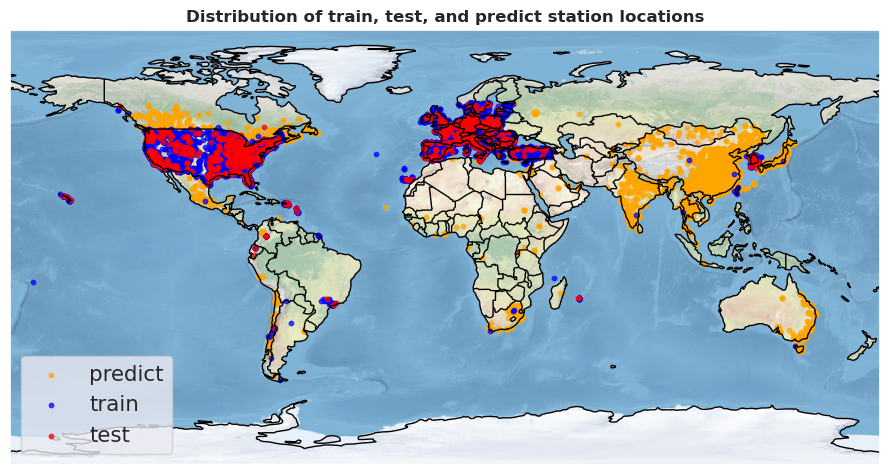

In [ ]:
# Create a figure and axes with Plate Carree projection
import cartopy.crs as ccrs
import cartopy
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.stock_img()
#ax.set_axis_on()
# Add coastlines and borders
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
# Plot earthquake locations with magnitude as size and color
#ax.scatter(lon_no2, lat_no2, s=10, color = 'blue',  alpha=0.7, label='no2')
#ax.scatter(lon_pm, lat_pm, s=10, color = 'orange',  alpha=0.7, label='pm2p5')
ax.scatter(lon_pred, lat_pred, s=10, color = 'orange',  alpha=0.7, label='predict')
ax.scatter(lon_train, lat_train, s=10, color = 'blue',  alpha=0.7, label='train')
ax.scatter(lon_test, lat_test, s=10, color = 'red', alpha=0.7, label='test')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribution of train, test, and predict station locations',fontsize=12)
plt.legend(loc='best')
#plt.savefig('figures/data_split.jpg', dpi=400, bbox_inches='tight')
plt.show()
# Add color bar legend

### ============================= END ==============================